<center>


<div style="display: flex; justify-content: center;">
    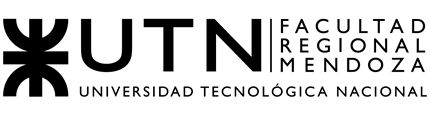
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Departamento de Ingeniería en Tecnologías Electrónicas</strong></p>
    </div>
</center>

# Módulo 6 — Clases y objetos

En los módulos anteriores aprendiste a trabajar con tipos de datos, colecciones, estructuras de control y funciones. Con esas herramientas ya podés resolver una enorme variedad de problemas. Este módulo agrega una idea nueva que no es **imprescindible** para escribir programas, pero sí es la **llave para entender** las librerías que vas a usar de ahora en adelante: NumPy, Matplotlib, SciPy.

La idea es la **programación orientada a objetos** (*object-oriented programming*, OOP). En lugar de tener, por un lado, los datos (variables, listas, diccionarios) y, por otro, las funciones que operan sobre esos datos, OOP **agrupa ambas cosas** en una sola unidad: un *objeto*. Un objeto guarda datos — llamados **atributos** — y sabe hacer cosas con ellos a través de funciones asociadas — llamadas **métodos**.

Los temas de este módulo son:

| Tema | Para qué sirve |
|------|----------------|
| Objetos que ya usaste | Reconocer que strings, listas y números complejos ya son objetos |
| Atributos y métodos | Distinguir los datos que guarda un objeto de las acciones que puede hacer |
| `class` e `__init__` | Definir un tipo de objeto propio |
| `self` | Cómo cada objeto se refiere a sí mismo |
| Métodos propios | Funciones asociadas al objeto que usan sus atributos |
| Herencia (mención) | Una clase que "hereda" lo que otra ya tenía |

> **Aviso importante.** En la práctica vas a **usar** muchas más clases de las que vas a **escribir**. El objetivo central de este módulo es que, cuando veas en un ejemplo algo como `señal.mean()` o `eje.plot(...)` o `sistema.step()`, entiendas qué está pasando y no te frene la sintaxis.

## 1. Objetos que ya venías usando

Sin haberlo dicho explícitamente, desde el Módulo 2 ya estuviste trabajando con objetos. Cada valor en Python **es** un objeto: una string es un objeto, una lista es un objeto, un número complejo es un objeto. Cada uno trae consigo:

- **Atributos**: datos que lleva adentro, a los que se accede con un punto: `objeto.atributo`.
- **Métodos**: funciones que operan sobre el propio objeto, también con un punto y paréntesis: `objeto.metodo(...)`.

Revisemos tres ejemplos que ya viste, ahora con vocabulario nuevo.

### Atributos en un número complejo

En el Módulo 2 usaste `.real` y `.imag` sobre un número complejo:

In [ ]:
z = 3 + 4j

print(z.real)   # atributo: parte real
print(z.imag)   # atributo: parte imaginaria

`z.real` **no lleva paréntesis**: no estás llamando a una función, estás leyendo un dato que el objeto `z` ya tiene guardado. Eso es un **atributo**.

### Métodos en una string

Las strings tienen métodos que devuelven versiones modificadas de la cadena:

In [ ]:
saludo = "hola mundo"

print(saludo.upper())        # método: devuelve la cadena en mayúsculas
print(saludo.replace("mundo", "Python"))

`saludo.upper()` **sí lleva paréntesis**: le estás pidiendo al objeto `saludo` que **ejecute** una acción. Eso es un **método**.

### Métodos en una lista

Las listas también tienen métodos, como `append()`, que ya usaste en el Módulo 3:

In [ ]:
valores = [10, 20, 30]
valores.append(40)
print(valores)

Fijate el patrón:

| Sintaxis | Qué es | Ejemplo |
|----------|--------|---------|
| `objeto.atributo` | Lee un dato guardado en el objeto | `z.real` |
| `objeto.metodo(...)` | Ejecuta una acción sobre el objeto | `lista.append(5)` |

Lo que vamos a aprender ahora es a **crear nuestros propios objetos**, con los atributos y métodos que nos resulten útiles.

## 2. Definir una clase

Una **clase** (*class*) es el molde con el que se fabrican objetos. Así como `int` es el molde para fabricar enteros y `list` es el molde para fabricar listas, nosotros podemos definir nuestro propio molde.

Un objeto creado a partir de una clase se llama **instancia** (*instance*) de esa clase. Cada vez que llamamos a la clase como si fuera una función, Python fabrica una nueva instancia.

Definamos una clase `Resistencia` que represente una resistencia eléctrica con su valor nominal (en ohms) y su tolerancia (en porcentaje):

In [ ]:
class Resistencia:
    def __init__(self, valor, tolerancia):
        self.valor = valor
        self.tolerancia = tolerancia

Tres cosas nuevas aparecen acá, vamos una por una.

### `class Resistencia:`

La palabra clave `class` seguida del nombre define una nueva clase. Por convención, los nombres de clase empiezan con **mayúscula** (`Resistencia`, `Senoidal`, `Filtro`), a diferencia de las variables y funciones que se escriben en minúscula. El cuerpo de la clase va indentado.

### `__init__`

`__init__` (con dos guiones bajos a cada lado — se pronuncia "dunder init") es un método especial: el **constructor**. Python lo llama automáticamente cada vez que fabricás una instancia nueva. Su trabajo es preparar el objeto recién creado: típicamente, guardar los datos iniciales en sus atributos.

### `self`

`self` es el primer parámetro de todos los métodos de la clase y representa **a la instancia que se está manipulando**. No hace falta pasárselo explícitamente al llamar al método: Python lo inserta solo.

Dentro del constructor, las líneas

```python
self.valor = valor
self.tolerancia = tolerancia
```

guardan los valores que recibió el constructor **dentro del objeto**, como atributos accesibles después con `objeto.valor` y `objeto.tolerancia`.

### Crear instancias y leer sus atributos

Ya podemos fabricar resistencias:

In [ ]:
r1 = Resistencia(220, 5)      # 220 Ω, 5%
r2 = Resistencia(4700, 1)     # 4.7 kΩ, 1%

print(r1.valor, r1.tolerancia)
print(r2.valor, r2.tolerancia)

Algunas observaciones importantes:

- Escribimos `Resistencia(220, 5)`, **sin** pasar `self`: Python se encarga de eso.
- `r1` y `r2` son **objetos distintos**, cada uno con sus propios atributos. Modificar uno no afecta al otro.
- Podés crear tantas instancias como quieras a partir de la misma clase.

### Actividad 1: una clase `Capacitor`

Definí una clase `Capacitor` que represente un capacitor eléctrico con dos atributos: `capacidad` (en farads) y `tension_max` (tensión máxima soportada, en volts).

1. Escribí la clase con su método `__init__`.
2. Creá dos instancias: `c1` con 1 µF y 25 V de tensión máxima, y `c2` con 100 nF y 50 V. (Recordá que 1 µF = `1e-6` F y 100 nF = `100e-9` F.)
3. Mostrá los atributos de cada capacitor con un f-string del estilo `"c1: C = ... F, V_max = ... V"`.

In [ ]:
# TU CÓDIGO AQUÍ

## 3. Métodos: funciones asociadas al objeto

Por ahora la clase `Resistencia` guarda datos pero no hace nada con ellos. Lo siguiente es agregarle **métodos**: funciones definidas dentro de la clase, que pueden usar los atributos del objeto.

Agreguemos un método `rango()` que devuelva los valores mínimo y máximo que puede tener la resistencia, teniendo en cuenta su tolerancia:

In [ ]:
class Resistencia:
    def __init__(self, valor, tolerancia):
        self.valor = valor
        self.tolerancia = tolerancia

    def rango(self):
        delta = self.valor * self.tolerancia / 100
        return self.valor - delta, self.valor + delta

Un método se define con `def`, igual que una función normal, pero con dos diferencias clave:

- Va **indentado dentro de la clase**.
- Su primer parámetro es **siempre** `self`, que Python usa para entregarle al método la instancia concreta sobre la que se está trabajando.

Adentro del método, `self.valor` y `self.tolerancia` son los atributos del objeto sobre el que se llamó al método. Probemos:

In [ ]:
r = Resistencia(1000, 5)    # 1 kΩ ± 5%

print(r.valor)              # atributo
minimo, maximo = r.rango()  # método: devuelve una tupla de dos valores
print(f"Rango: {minimo:.1f} Ω a {maximo:.1f} Ω")

Al escribir `r.rango()`, Python entiende que `self` es `r` y ejecuta el cuerpo del método usando los atributos de esa instancia. Si hubiéramos llamado `r2.rango()` sobre otra resistencia distinta, el mismo código trabajaría con los atributos de `r2`.

> **Nota.** Los atributos viven **adentro** del objeto: para acceder a ellos desde un método hay que escribir `self.valor`, **no** simplemente `valor`. Sin el `self.`, Python pensaría que `valor` es una variable local y no la encontraría.

### Actividad 2: método `energia()` en `Capacitor`

La energía almacenada en un capacitor cargado a una tensión $V$ vale

$$E = \frac{1}{2} C V^2$$

donde $E$ está en joules, $C$ en farads y $V$ en volts.

1. Reescribí la clase `Capacitor` de la actividad 1 agregándole un método `energia(v)` que, dada una tensión `v`, devuelva la energía almacenada.
2. Creá un capacitor de 10 µF y 25 V de tensión máxima.
3. Calculá y mostrá la energía almacenada cuando está cargado a 10 V. Mostrala en milijoules (1 J = 1000 mJ) con tres decimales.

In [ ]:
# TU CÓDIGO AQUÍ

## 4. Un objeto con más vida: una señal senoidal

Hasta ahora la clase `Resistencia` era, en esencia, un contenedor de datos con un cálculo simple. Veamos un ejemplo donde el objeto tiene más trabajo por delante: una **señal senoidal**.

Una señal senoidal queda definida por tres parámetros:

$$x(t) = A \sin(2\pi f t + \varphi)$$

- amplitud $A$,
- frecuencia $f$ en hertz,
- fase inicial $\varphi$ en radianes.

Vamos a encapsular estos tres datos y el cálculo del valor instantáneo en una clase. Como vamos a usar `sin` y $\pi$, importamos de `math`:

In [ ]:
from math import sin, pi

class Senoidal:
    def __init__(self, amplitud, frecuencia, fase=0.0):
        self.amplitud = amplitud
        self.frecuencia = frecuencia
        self.fase = fase

    def valor_en(self, t):
        return self.amplitud * sin(2 * pi * self.frecuencia * t + self.fase)

    def periodo(self):
        return 1 / self.frecuencia

Algunas cosas para notar:

- El parámetro `fase` tiene **valor por defecto** `0.0`, igual que en las funciones del Módulo 5. Si no se especifica, la señal arranca en fase cero.
- `valor_en(self, t)` usa los tres atributos del objeto (`amplitud`, `frecuencia`, `fase`) para calcular el valor instantáneo.
- `periodo(self)` **no recibe ningún argumento además de `self`**: trabaja solo con los datos que ya tiene el objeto.

Probémosla:

In [ ]:
s1 = Senoidal(amplitud=1.0, frecuencia=50, fase=0.0)   # 50 Hz, amplitud 1
s2 = Senoidal(amplitud=0.5, frecuencia=1000)           # 1 kHz, fase por defecto

print(f"Período de s1: {s1.periodo() * 1000:.2f} ms")
print(f"Período de s2: {s2.periodo() * 1000:.2f} ms")

print(f"s1 en t = 5 ms: {s1.valor_en(0.005):.4f}")
print(f"s1 en t = 10 ms: {s1.valor_en(0.010):.4f}")

> **Leelo con atención.** Cada instancia lleva consigo sus parámetros y sabe calcular su propio valor. No hay una variable global "amplitud" ni "frecuencia" que ande dando vueltas por el programa: cada señal encapsula lo suyo.

### Varias instancias conviven sin pisarse

Como `s1` y `s2` son objetos independientes, podemos manejar varias señales a la vez sin confusión:

In [ ]:
señales = [
    Senoidal(1.0, 50),       # señal de línea: 50 Hz
    Senoidal(0.3, 440),      # nota musical La4: 440 Hz
    Senoidal(0.1, 1000),     # tono de 1 kHz
]

for s in señales:
    print(f"f = {s.frecuencia} Hz  →  T = {s.periodo()*1000:.3f} ms")

Guardamos tres objetos `Senoidal` en una lista y recorremos esa lista con un `for`. Dentro del bucle, `s` es, sucesivamente, cada una de las señales, y podemos consultarle sus atributos o llamarle sus métodos.

Este patrón — una colección de objetos del mismo tipo, recorrida con un `for` — es **exactamente** lo que vas a encontrar cuando más adelante trabajes con listas de componentes, listas de ejes en Matplotlib, o listas de sistemas en SciPy.

### Actividad 3: clase `CircuitoRC`

Un circuito RC de primer orden queda caracterizado por dos parámetros: la resistencia $R$ (en Ω) y el capacitor $C$ (en F). A partir de ellos se derivan dos cantidades importantes:

- la **constante de tiempo** $\tau = R \cdot C$ (en segundos);
- la **frecuencia de corte** $f_c = \dfrac{1}{2\pi R C}$ (en hertz).

Definí una clase `CircuitoRC`:

1. Su `__init__` recibe `r` y `c` y los guarda como atributos.
2. Agregale un método `tau()` que devuelva la constante de tiempo.
3. Agregale un método `frecuencia_corte()` que devuelva la frecuencia de corte. Podés importar `pi` de `math`.
4. Creá el circuito `rc = CircuitoRC(r=10000, c=100e-9)` (10 kΩ y 100 nF).
5. Mostrá la constante de tiempo en microsegundos y la frecuencia de corte en hertz, ambos con dos decimales.

In [ ]:
from math import pi

# TU CÓDIGO AQUÍ

## 5. Evaluar una señal en varios instantes

Una vez que tenemos el objeto `Senoidal`, es muy natural evaluarla en muchos instantes y guardarlos en una lista. Podemos hacerlo con un `for` o con una comprensión de lista (ambos vistos en M04):

In [ ]:
from math import sin, pi

class Senoidal:
    def __init__(self, amplitud, frecuencia, fase=0.0):
        self.amplitud = amplitud
        self.frecuencia = frecuencia
        self.fase = fase

    def valor_en(self, t):
        return self.amplitud * sin(2 * pi * self.frecuencia * t + self.fase)

s = Senoidal(amplitud=1.0, frecuencia=50)

# Instantes equiespaciados: 0, 1, 2, ..., 9 milisegundos
instantes = [i * 0.001 for i in range(10)]
muestras = [s.valor_en(t) for t in instantes]

for t, y in zip(instantes, muestras):
    print(f"t = {t*1000:5.1f} ms   x(t) = {y: .4f}")

Este es el momento en el que empezás a **ver** cómo se construye una señal muestreada a partir de una descripción continua. Por ahora lo hacemos a mano con listas y bucles; más adelante, en el Módulo 7, NumPy te va a permitir hacer lo mismo en una sola línea y con arrays vectorizados.

> **Detalle útil.** `zip(a, b)` recorre dos secuencias en paralelo, emparejando el primer elemento de `a` con el primero de `b`, y así sucesivamente. Es una forma cómoda de iterar dos listas relacionadas.

### Actividad 4: comparar dos señales

Reutilizando la clase `Senoidal` ya definida:

1. Creá dos señales: `s_baja` de 50 Hz y amplitud 1, y `s_alta` de 500 Hz y amplitud 0.2, ambas con fase cero.
2. Generá una lista `instantes` con 21 valores equiespaciados entre 0 y 20 ms. Podés hacerlo con `[i * 0.001 for i in range(21)]`.
3. Generá las listas `muestras_baja` y `muestras_alta` aplicando `valor_en(...)` a cada instante.
4. Recorré las tres listas en paralelo con `zip` y mostrá cada fila con un f-string, por ejemplo:
   ```
   t =  0.0 ms   baja =  0.0000   alta =  0.0000
   t =  1.0 ms   baja =  0.3090   alta =  0.1902
   ...
   ```
   (con cuatro decimales en los valores).

In [ ]:
# TU CÓDIGO AQUÍ

## 6. Herencia (breve mención)

Python permite que una clase **herede** atributos y métodos de otra. Por ejemplo, podríamos tener una clase general `Componente` con un atributo `nombre`, y luego clases más específicas como `Resistencia` o `Capacitor` que "hereden" de `Componente` y agreguen sus propios atributos y métodos. La sintaxis básica es:

```python
class Resistencia(Componente):
    ...
```

**No vamos a profundizar acá**: es una herramienta avanzada que, en la práctica, vas a **leer** en el código de las librerías mucho antes de que necesites escribirla vos. Mencionarla sirve para que, cuando la veas, sepas qué es.

## Cierre

En este módulo diste el salto conceptual de "datos + funciones por separado" a "objetos que llevan adentro sus datos y sus acciones":

- **Objetos y clases**: una clase es el molde, un objeto es una instancia fabricada con ese molde.
- **Atributos y métodos**: los atributos son los datos que guarda el objeto (`objeto.atributo`); los métodos son las funciones asociadas que saben trabajar con esos datos (`objeto.metodo(...)`).
- **`__init__` y `self`**: el constructor arma cada instancia al momento de crearla; `self` es la referencia que cada método tiene a la instancia sobre la que está trabajando.
- **Herencia**: existe como mecanismo para extender clases; por ahora basta con saber que la sintaxis `class Hija(Madre):` significa exactamente eso.

La buena noticia es que, de ahora en adelante, casi todo lo que uses en Python va a estar hecho de objetos: un array de NumPy es un objeto con su método `.mean()`, una figura de Matplotlib es un objeto con métodos para agregar curvas, un sistema de SciPy es un objeto con métodos para obtener su respuesta al escalón. Toda la sintaxis de puntos que vas a ver de acá en adelante — `arr.shape`, `fig.savefig(...)`, `sistema.step()` — ahora debería dejar de parecer magia.

**En el próximo módulo** vamos a ver **NumPy**, la librería central para trabajar con arreglos numéricos en Python. Vas a ver muchos objetos `ndarray` y sus métodos; con lo que aprendiste acá, la sintaxis no te va a tomar por sorpresa.